# Trabalho Prático 1 - Agente Inteligente em Labirinto
**Disciplina:** CSI457 - Inteligência Artificial (2026-1)
**Curso:** Sistemas de Informação - UFOP

---

## 1. Parte I - Projeto do Agente Inteligente

### Modelagem PEAS
* **Performance (Função de Desempenho $J$):** $J = -\text{custo caminho} - \text{nós expandidos} - \text{tempo execução} - \text{mov inválidos} - \text{células revisitadas}$.
* **Environment (Ambiente):** Grade bidimensional (matriz) com paredes (`#`), posição inicial (`A`), objetivo final (`B`), pontos de coleta (`C`) e células desconhecidas (`?`) no modo online.
* **Actuators (Atuadores):** Movimentos ortogonais: {cima, baixo, esquerda, direita}.
* **Sensors (Sensores):** Mapa completo visível na busca clássica; percepção local com raio $r=1$ na busca online.

### Classificação do Agente
O agente é classificado como um **agente baseado em objetivos com modelo interno**, pois ele mantém um estado interno do mapa (especialmente no modo online) para planejar suas ações em direção ao objetivo final `B`.

## 2. Configuração Inicial e Interpretador de Mapas
Abaixo está a função responsável por ler o arquivo de texto do labirinto (ou uma string direta) e transformá-lo em uma estrutura de matriz (lista de listas de strings) para alimentar os algoritmos de busca.

In [1]:
#atualiza o código automaticamente 
%load_ext autoreload
%autoreload 2
import os

def interpretar_labirinto(alvo):
    """
    Interpreta o labirinto a partir de um arquivo .txt OU de uma string direta.
    Retorna uma matriz e as coordenadas dos pontos importantes.
    """
    # Se o alvo for um caminho de arquivo existente, lê o arquivo
    if isinstance(alvo, str) and os.path.exists(alvo):
        with open(alvo, 'r', encoding='utf-8') as arquivo:
            texto_labirinto = arquivo.read()
    else:
        # Caso contrário, assume que já é a própria string do labirinto
        texto_labirinto = alvo

    mapa_matriz = []
    inicio = None
    objetivo = None
    coletas = []
    
    # Divide por linhas e remove linhas vazias
    linhas = [l for l in texto_labirinto.split('\n') if l.strip()]

    pontos_encontrados = {}
    contador_c = 1
    
    for i, linha in enumerate(linhas):
        linha_lista = list(linha.replace('\r', ''))
        mapa_matriz.append(linha_lista)
        
        for j, caractere in enumerate(linha_lista):
            if caractere == 'A':
                inicio = (i, j)
                pontos_encontrados['A'] = (i, j)
            elif caractere == 'B':
                objetivo = (i, j)
                pontos_encontrados['B'] = (i, j)
            elif caractere == 'C':
                coletas.append((i, j))
                pontos_encontrados[f'C{contador_c}'] = (i, j)
                contador_c += 1
                
    return {
        "matriz": mapa_matriz,
        "inicio": inicio,
        "objetivo": objetivo,
        "coletas": coletas,
        "dimensoes": (len(mapa_matriz), len(mapa_matriz[0]) if mapa_matriz else 0),
        "pontos_encontrados": pontos_encontrados
    }

def exibir_labirinto(matriz):
    """Função auxiliar para plotar o labirinto bonitinho no terminal do Jupyter"""
    for linha in matriz:
        print(" ".join(linha))

In [2]:
labirinto_teste = "mapas/mapa2.txt"

# Carregando os dados que todo mundo do grupo vai usar nas próximas células
dados = interpretar_labirinto(labirinto_teste)

# Validando se leu tudo certo
print("--- DADOS DO LABIRINTO CARREGADOS ---")
print(f"Posição Inicial (A): {dados['inicio']}")
print(f"Objetivo Final (B): {dados['objetivo']}")
print(f"Pontos de Coleta (C): {dados['coletas']}")
print(f"Dimensões: {dados['dimensoes'][0]}x{dados['dimensoes'][1]}\n")
print("Visualização do mapa:")
exibir_labirinto(dados["matriz"])

--- DADOS DO LABIRINTO CARREGADOS ---
Posição Inicial (A): (1, 1)
Objetivo Final (B): (7, 9)
Pontos de Coleta (C): [(1, 8), (3, 4), (5, 7), (5, 9), (7, 1)]
Dimensões: 9x11

Visualização do mapa:
# # # # # # # # # # #
# A     #       C   #
#   #   #   # # #   #
#   #   C       #   #
#   # # # # #   #   #
#             C # C #
#   # # #   # # #   #
# C     #         B #
# # # # # # # # # # #


## 3. Parte II - Busca Clássica no Labirinto Conhecido

Nesta etapa, os algoritmos têm acesso total à variável `dados["matriz"]`.
* **Início:** `dados["inicio"]`
* **Fim:** `dados["objetivo"]`

In [3]:
import time
import pandas as pd
from src.busca_classica import (
    TenhoQueExplorar_BFS, 
    TenhoQueExplorar_DFS, 
    TenhoQueExplorar_Prioridade, 
    executar_busca_classica
)

# Dicionário mapeando o nome do algoritmo à instância da sua respectiva fronteira
fabrica_algoritmos = {
    "BFS": TenhoQueExplorar_BFS(),
    "DFS": TenhoQueExplorar_DFS(),
    "UCS": TenhoQueExplorar_Prioridade(criterio="custo"),
    "Gulosa": TenhoQueExplorar_Prioridade(criterio="heuristica"),
    "A*": TenhoQueExplorar_Prioridade(criterio="total_f")
}

linhas_tabela = []

print("--- EXECUTANDO BENCHMARK DE BUSCA CLÁSSICA ---")

for nome, fronteira_algo in fabrica_algoritmos.items():
    # Medição precisa de tempo usando timer de alta resolução
    tempo_inicio = time.perf_counter()
    resultado = executar_busca_classica(dados, fronteira_algo)
    tempo_fim = time.perf_counter()
    
    duracao_ms = (tempo_fim - tempo_inicio) * 1000
    
    linhas_tabela.append({
        "Algoritmo": nome,
        "Sucesso": resultado["sucesso"],
        "Custo": resultado.get("custo", "-"),
        "Passos": resultado.get("passos", "-"),
        "Explorados": resultado.get("explorados", "-"),
        "Expandidos": resultado.get("expandidos", "-"),
        "Tempo (ms)": round(duracao_ms, 4),
        "Fronteira Max": resultado.get("fronteira_max", "-")
    })

# Transforma em DataFrame para exibição profissional no Jupyter Notebook
df_resultados = pd.DataFrame(linhas_tabela)
display(df_resultados)

# Salva opcionalmente em CSV para cumprir os entregáveis finais do projeto!
# df_resultados.to_csv("resultados_busca_classica.csv", index=False)

--- EXECUTANDO BENCHMARK DE BUSCA CLÁSSICA ---


,Algoritmo,Sucesso,Custo,Passos,Explorados,Expandidos,Tempo (ms),Fronteira Max
0,BFS,True,14,14,38,36,0.1674,4
1,DFS,True,18,18,32,29,0.1238,5
2,UCS,True,14,14,39,36,0.0912,4
3,Gulosa,True,14,14,21,18,0.0383,3
4,A*,True,14,14,32,29,0.0565,4


## 4. Parte III - Busca Local com Pontos de Coleta

Nesta etapa, o objetivo deixa de ser ir do ponto A ao B, e passa a ser encontrar a melhor ordem de visitação para múltiplos pontos de coleta (`C`) no labirinto. Utilizamos a matriz de distâncias gerada pelo $A^*$ e aplicamos os algoritmos de **Hill-Climbing** e **Simulated Annealing** para otimizar o caminho.

Construindo GPS com A*...
Executando Simulated Annealing...
Iniciando 30 execucoes. Aguarde...
METRICAS OBRIGATORIAS (30 Rodadas)
Melhor custo: 32
Pior custo: 32
Custo medio: 32.00
Tempo medio: 0.001953 segundos
Iteracoes medias: 225.6 passos aceitos
Taxa de Sucesso: 100.0%

Executando Hill-Climbing...
Iniciando 30 execucoes. Aguarde...
METRICAS OBRIGATORIAS (30 Rodadas)
Melhor custo: 32
Pior custo: 46
Custo medio: 33.87
Tempo medio: 0.001917 segundos
Iteracoes medias: 3.5 passos aceitos
Taxa de Sucesso: 86.7%


Grafico 'grafico_convergencia.png' gerado com sucesso!


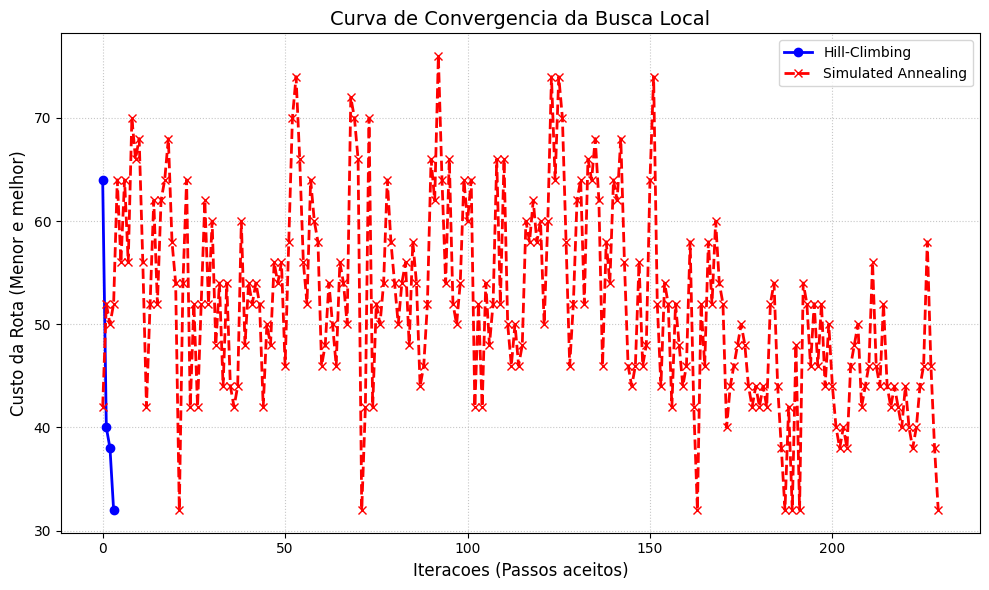

In [ ]:
from src.busca_local import teste, hill_climbing, simulated_annealing, construir_gps, gerar_grafico_convergencia

# O Notebook já leu a matriz na variável 'dados' nas células anteriores
matriz_atual = dados["matriz"]

pontos_encontrados = dados["pontos_encontrados"]

print("Construindo GPS com A*...")

from src import busca_local

busca_local.dicionario_real = construir_gps(
    matriz_atual,
    pontos_encontrados
)

lista_de_coletas = [p for p in pontos_encontrados.keys() if p not in ['A', 'B']]

print("Executando Hill-Climbing...")
historico_hc = teste(hill_climbing, lista_de_coletas, repeticoes=30)

print("Executando Simulated Annealing...")
historico_sa = teste(simulated_annealing, lista_de_coletas, repeticoes=30)

gerar_grafico_convergencia(historico_hc, historico_sa)